# RoPE: Rotary Position Embeddings From Scratch

We use **SmolLM2-135M** (`HuggingFaceTB/SmolLM2-135M`) and follow the first attention layer of the real model to see exactly what RoPE does to Q and K.

We first reproduce the operation ourselves, then compare it with the model's own implementation.

**Outline**
1. Inspect the attention configuration and confirm that RoPE is in the attention path.
2. Build Q, K and V for a 6-token sentence and split them into heads.
3. See how a 64-dim head is organised into 32 rotation pairs.
4. Find the RoPE module, its 32 frequencies, and the per-position angles, cosines and sines.
5. Rotate one pair by hand, then a whole head, then every position.
6. Check that the length is preserved and that the result matches Hugging Face's `apply_rotary_pos_emb` exactly.
7. Why both Q and K are rotated: the relative-position property.

In [70]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM

torch.set_printoptions(
    precision=4,
    sci_mode=False,
    linewidth=160
)

MODEL_NAME = "HuggingFaceTB/SmolLM2-135M"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float32
)

model.eval()

print("Model loaded:", MODEL_NAME)

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Model loaded: HuggingFaceTB/SmolLM2-135M


## Inspect the attention configuration

Before touching RoPE, establish the dimensions of the real attention tensors in SmolLM:

- `hidden_size = 576`, split into **9 query heads × 64 dims**
- **3 key/value heads** (grouped-query attention: each K/V head is shared by 3 query heads)
- `rope_theta = 100000`, the base used to compute the RoPE frequencies. This is 10× the original SmolLM's 10000, which makes the slow pairs rotate even more slowly. That suits SmolLM2's longer context (`max_position_embeddings = 8192`).

RoPE operates on each 64-dim head vector independently.

In [71]:
config = model.config

print("Hidden size     :", config.hidden_size)
print("Attention heads :", config.num_attention_heads)
print("KV heads        :", config.num_key_value_heads)
print("Head dimension  :", config.hidden_size // config.num_attention_heads)
print("Layers          :", config.num_hidden_layers)
print("Max positions   :", config.max_position_embeddings)
print("RoPE parameters :", config.rope_parameters)

Hidden size     : 576
Attention heads : 9
KV heads        : 3
Head dimension  : 64
Layers          : 30
Max positions   : 8192
RoPE parameters : {'rope_theta': 100000, 'rope_type': 'default'}


## Verify that the attention layer actually uses RoPE

The configuration tells us that RoPE parameters exist.

Now we will inspect the actual attention layer and verify that
Q and K are passed through the rotary positional embedding operation.

In [72]:
import inspect

attention = model.model.layers[0].self_attn

source = inspect.getsource(attention.forward)

print(source)

    def forward(
        self,
        hidden_states: torch.Tensor,
        position_embeddings: tuple[torch.Tensor, torch.Tensor] | None = None,
        attention_mask: torch.Tensor | None = None,
        past_key_values: Cache | None = None,
        **kwargs: Unpack[TransformersKwargs],
    ) -> tuple[torch.Tensor, torch.Tensor]:
        input_shape = hidden_states.shape[:-1]
        hidden_shape = (*input_shape, -1, self.head_dim)

        query_states = self.q_proj(hidden_states).view(hidden_shape).transpose(1, 2)
        key_states = self.k_proj(hidden_states).view(hidden_shape).transpose(1, 2)
        value_states = self.v_proj(hidden_states).view(hidden_shape).transpose(1, 2)

        cos, sin = position_embeddings
        query_states, key_states = apply_rotary_pos_emb(query_states, key_states, cos, sin)

        if past_key_values is not None:
            key_states, value_states = past_key_values.update(key_states, value_states, self.layer_idx)

        attention_interface: C

## Create the input sequence

Now that we've confirmed RoPE is part of the attention path, create the short sentence we'll trace through the model: `"The cat sat on the mat"`.

It tokenizes into **six tokens (positions 0–5)**. That is short enough to print everything, and long enough to see the rotation grow with position.

In [73]:
text = "The cat sat on the mat"

inputs = tokenizer(
    text,
    return_tensors="pt"
)

input_ids = inputs["input_ids"]

print("Input IDs:")
print(input_ids)

print("\nTokens:")
for position, token_id in enumerate(input_ids[0]):
    print(f"{position}: {repr(tokenizer.decode([token_id]))}")

Input IDs:
tensor([[ 504, 2644, 2643,  335,  260, 1171]])

Tokens:
0: 'The'
1: ' cat'
2: ' sat'
3: ' on'
4: ' the'
5: ' mat'


## Get the token embeddings

The first transformer layer receives one embedding vector for each
token.

For this model, each token is represented by a 576-dimensional
vector.

We will use these real embeddings as the starting point for our
RoPE walkthrough.

In [74]:
embed_tokens = model.model.embed_tokens

X = embed_tokens(input_ids)

print("Embedding shape:", X.shape)

Embedding shape: torch.Size([1, 6, 576])


## Compute Q, K and V

Now enter the first transformer layer and project the embeddings with its `q_proj`, `k_proj` and `v_proj`:

- **Q** (query): 576 wide, for the 9 query heads
- **K** (key) and **V** (value): 192 wide, for the 3 KV heads

RoPE will be applied to Q and K. **V is never rotated.**

> **Simplification:** the real layer first applies `input_layernorm` (RMSNorm) to the embeddings and projects the *normalized* vectors. We project the raw embeddings `X` directly. The Q/K values therefore differ slightly from what the model computes, but that doesn't affect the RoPE check, because the manual and model rotations below are both applied to these same Q/K tensors.

In [75]:
layer = model.model.layers[0]
attention = layer.self_attn

Q = attention.q_proj(X)
K = attention.k_proj(X)
V = attention.v_proj(X)

print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)

Q shape: torch.Size([1, 6, 576])
K shape: torch.Size([1, 6, 192])
V shape: torch.Size([1, 6, 192])


## Split Q, K and V into attention heads

The 576-dimensional Q is not one 576-dimensional attention vector.

SmolLM has:

- 9 query heads
- 3 key/value heads
- 64 dimensions per head

So Q becomes 9 vectors of 64 dimensions, while K and V become
3 vectors of 64 dimensions.

RoPE operates on these 64-dimensional Q/K head vectors.

In [76]:
batch_size, seq_len, _ = Q.shape

num_q_heads = config.num_attention_heads
num_kv_heads = config.num_key_value_heads
head_dim = config.hidden_size // num_q_heads

Q_heads = Q.view(
    batch_size, seq_len, num_q_heads, head_dim
).transpose(1, 2)

K_heads = K.view(
    batch_size, seq_len, num_kv_heads, head_dim
).transpose(1, 2)

V_heads = V.view(
    batch_size, seq_len, num_kv_heads, head_dim
).transpose(1, 2)

print("Q heads:", Q_heads.shape)
print("K heads:", K_heads.shape)
print("V heads:", V_heads.shape)

Q heads: torch.Size([1, 9, 6, 64])
K heads: torch.Size([1, 3, 6, 64])
V heads: torch.Size([1, 3, 6, 64])


## Look at one real Q head

Let's focus on one Q head and one token.

A head has 64 dimensions.

In SmolLM's actual Hugging Face implementation, RoPE treats these
64 dimensions as 32 rotation pairs, but the two coordinates of each
pair are stored in separate halves of the vector:

`(q0, q32), (q1, q33), ..., (q31, q63)`

So dimension pair `i` consists of:

`q[i]` and `q[i + 32]`

Each pair is an independent 2D rotation plane.

In [77]:
head = 0
position = 0

q = Q_heads[0, head, position]

print("Q head:", head)
print("Token position:", position)
print("Q shape:", q.shape)

print("\nFirst half:")
print(q[:32])

print("\nSecond half:")
print(q[32:])

print("\nFirst 4 actual RoPE pairs:")
for i in range(4):
    print(f"Pair {i}: ({q[i].item():.4f}, {q[i + 32].item():.4f})")

print("...")
print(f"Pair 31: ({q[31].item():.4f}, {q[63].item():.4f})")

Q head: 0
Token position: 0
Q shape: torch.Size([64])

First half:
tensor([-0.4670, -0.7287, -0.1865, -0.5829,  0.5640, -0.6048,  0.6203,  0.8375, -0.3967,  0.5568, -0.3638, -0.2149,  0.0007, -0.4341,  0.4517,  0.1352, -0.0362,
         0.2985, -0.0718,  0.3973,  0.3427, -0.1467, -0.4323, -0.1029,  0.1230,  0.1242,  0.0176,  0.1196, -0.2155, -0.0864,  0.1414,  0.0201],
       grad_fn=<SliceBackward0>)

Second half:
tensor([ 0.1544, -0.2569,  0.3971,  0.8120, -0.0814,  0.2255, -0.3763, -0.0953, -0.2349,  0.3070, -0.1756,  0.3860,  0.2679, -0.6995,  0.0508,  0.2893,  0.1182,
         0.6405,  0.1495, -0.4115,  0.0007,  0.2278,  0.4132,  0.1607, -0.1204,  0.1460, -0.2171,  0.4938,  0.1155,  0.5856, -0.1459, -0.1918],
       grad_fn=<SliceBackward0>)

First 4 actual RoPE pairs:
Pair 0: (-0.4670, 0.1544)
Pair 1: (-0.7287, -0.2569)
Pair 2: (-0.1865, 0.3971)
Pair 3: (-0.5829, 0.8120)
...
Pair 31: (0.0201, -0.1918)


## Visualize the 32 actual RoPE rotation pairs

The 64 dimensions form 32 independent 2D rotation planes.

For pair `i`, the two coordinates are:

`(q[i], q[i + 32])`

Let's visualize these 32 actual pairs as points in a 2D plane.

Each point represents one rotation plane that RoPE will rotate
independently.

These are the values for token **position 0**, where every angle is 0, so RoPE leaves all 32 points where they are. The actual rotation is shown later, at position 3.

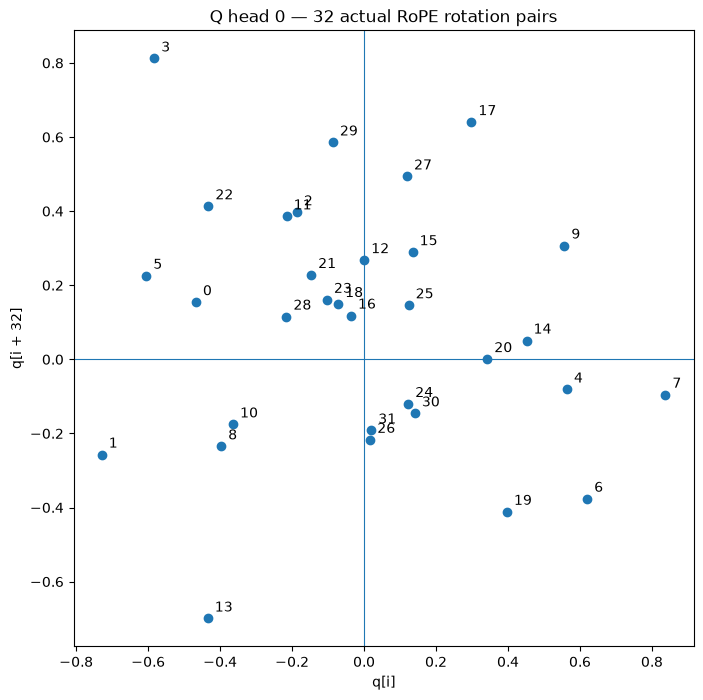

In [78]:
pairs = torch.stack(
    [q[:32], q[32:]],
    dim=1
).detach().numpy()

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    pairs[:, 0],
    pairs[:, 1]
)

for i, (x, y) in enumerate(pairs):
    ax.annotate(
        str(i),
        (x, y),
        xytext=(5, 5),
        textcoords="offset points"
    )

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

ax.set_xlabel("q[i]")
ax.set_ylabel("q[i + 32]")
ax.set_title("Q head 0 — 32 actual RoPE rotation pairs")

plt.show()

## Locate the RoPE module

The causal-LM wrapper doesn't expose the rotary embedding directly, so search the module tree for it.

It lives at `model.model.rotary_emb`. A **single** RoPE module is shared by all 30 layers. It computes `cos` / `sin` once per forward pass and passes them to every attention layer as `position_embeddings`, which is the `cos, sin = position_embeddings` line in the source printed above.

In [79]:
rotary = None

for name, module in model.named_modules():
    if "rotary_emb" in name.lower():
        print("Found:", name)
        print("Type :", type(module))
        rotary = module
        break

Found: model.rotary_emb
Type : <class 'transformers.models.llama.modeling_llama.LlamaRotaryEmbedding'>


## Inspect the frequencies used by RoPE

The RoPE module stores **32 frequencies** (`inv_freq`), one per rotation pair of the 64-dim head. Pair `i` uses:

`inv_freq[i] = 1 / theta^(2i / 64) = 100000^(-i / 32)`

So `inv_freq[0] = 1.0`, `inv_freq[1] ≈ 0.70`, …, `inv_freq[31] ≈ 0.000014`. These values are fixed by the RoPE configuration (`rope_theta`). They are **not** learned weights.

In [80]:
print("RoPE type :", config.rope_parameters["rope_type"])
print("RoPE theta:", config.rope_parameters["rope_theta"])

print("\nNumber of frequencies:", rotary.inv_freq.numel())

print("\ninv_freq:")
print(rotary.inv_freq)

RoPE type : default
RoPE theta: 100000

Number of frequencies: 32

inv_freq:
tensor([1.0000, 0.6978, 0.4870, 0.3398, 0.2371, 0.1655, 0.1155, 0.0806, 0.0562, 0.0392, 0.0274, 0.0191, 0.0133, 0.0093, 0.0065, 0.0045, 0.0032, 0.0022, 0.0015,
        0.0011, 0.0007, 0.0005, 0.0004, 0.0003, 0.0002, 0.0001, 0.0001, 0.0001, 0.0000, 0.0000, 0.0000, 0.0000])


## See how the frequencies differ

Each of the 32 pairs gets a different frequency. Pair 0 is the fastest (1 radian per token), and each later pair is about 30% slower than the one before. The frequencies fall geometrically from 1.0 to about 1.4e-5, which is why they appear as a **straight line on a log scale**.

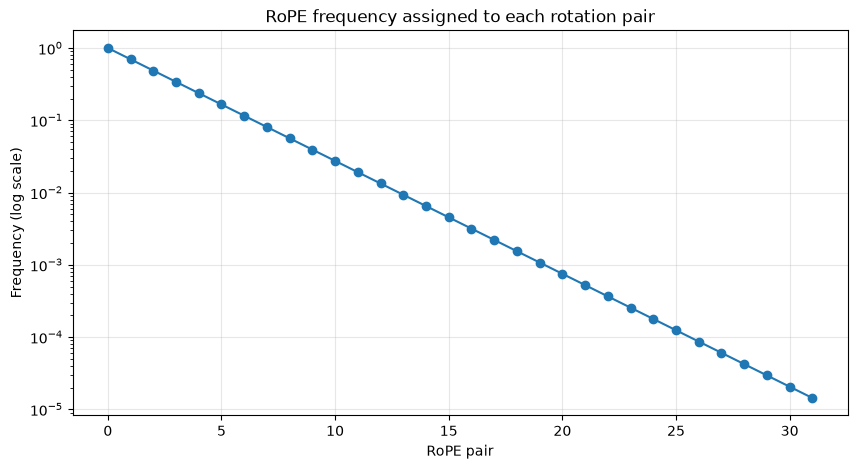

In [81]:
frequencies = rotary.inv_freq.detach().numpy()

plt.figure(figsize=(10, 5))

plt.plot(
    range(len(frequencies)),
    frequencies,
    marker="o"
)

plt.yscale("log")

plt.xlabel("RoPE pair")
plt.ylabel("Frequency (log scale)")
plt.title("RoPE frequency assigned to each rotation pair")

plt.grid(True, alpha=0.3)

plt.show()

## Convert frequency into a position-dependent rotation angle

`inv_freq` is the rotation **speed** of each pair. For token position `p`, the rotation **angle** of pair `i` is:

`angle[p, i] = p × inv_freq[i]`

The same pair therefore rotates further at later positions. The result is a `[6 positions × 32 pairs]` matrix. Row 0 is all zeros, because position 0 is never rotated.

Another way to read the speeds is as wavelengths. Pair 0 completes a full turn every 2π ≈ 6.3 tokens, while pair 31 needs about 440,000 tokens. Fast pairs distinguish nearby positions, and slow pairs change only over long distances.

In [82]:
position_ids = torch.arange(seq_len)

angles = position_ids[:, None] * rotary.inv_freq[None, :]

print("Position IDs:")
print(position_ids)

print("\nAngles shape:", angles.shape)

print("\nAngles [position × RoPE pair]:")
print(angles)

Position IDs:
tensor([0, 1, 2, 3, 4, 5])

Angles shape: torch.Size([6, 32])

Angles [position × RoPE pair]:
tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [1.0000, 0.6978, 0.4870, 0.3398, 0.2371, 0.1655, 0.1155, 0.0806, 0.0562, 0.0392, 0.0274, 0.0191, 0.0133, 0.0093, 0.0065, 0.0045, 0.0032, 0.0022, 0.0015,
         0.0011, 0.0007, 0.0005, 0.0004, 0.0003, 0.0002, 0.0001, 0.0001, 0.0001, 0.0000, 0.0000, 0.0000, 0.0000],
        [2.0000, 1.3957, 0.9739, 0.6796, 0.4743, 0.3310, 0.2310, 0.1612, 0.1125, 0.0785, 0.0548, 0.0382, 0.0267, 0.0186, 0.0130, 0.0091, 0.0063, 0.0044, 0.0031,
         0.0021, 0.0015, 0.0010, 0.0007, 0.0005, 0.0004, 0.0002, 0.0002, 0.0001, 0.0001, 0.0001, 0.0000, 0.0000],
        [3.0000, 2.0935, 1.4609, 1.0195, 0.7114, 0.4964, 0.3464, 0.

## Inspect the rotation angles for different RoPE pairs

Isolate four pairs: 0, 1, 10 and 31.

- **Pair 0** turns 1 radian per token, so it is already at 5 rad (≈ 286°) by position 5.
- **Pair 1** is a little slower (≈ 0.70 rad per token), reaching 3.49 rad by position 5.
- **Pair 10** has moved only 0.14 rad by position 5.
- **Pair 31** has barely moved (0.00007 rad).

This is how different dimensions get different positional "speeds".

In [83]:
selected_pairs = [0, 1, 10, 31]

print("Position | " + " | ".join(f"Pair {i}" for i in selected_pairs))
print("-" * 50)

for p in range(seq_len):
    values = [angles[p, i].item() for i in selected_pairs]
    print(
        f"{p:8d} | "
        + " | ".join(f"{v:.6f}" for v in values)
    )

Position | Pair 0 | Pair 1 | Pair 10 | Pair 31
--------------------------------------------------
       0 | 0.000000 | 0.000000 | 0.000000 | 0.000000
       1 | 1.000000 | 0.697831 | 0.027384 | 0.000014
       2 | 2.000000 | 1.395661 | 0.054768 | 0.000029
       3 | 3.000000 | 2.093492 | 0.082153 | 0.000043
       4 | 4.000000 | 2.791322 | 0.109537 | 0.000057
       5 | 5.000000 | 3.489153 | 0.136921 | 0.000072


## Turn the angles into cosine and sine

RoPE does not directly multiply Q and K by the angle.

For every token position and every RoPE pair, we compute:

`cos(angle)` and `sin(angle)`

These values determine how much that 2D pair is rotated.

Let's calculate the cosine and sine values used by our manual
implementation.

In [84]:
cos_angles = torch.cos(angles)
sin_angles = torch.sin(angles)

print("cos shape:", cos_angles.shape)
print("sin shape:", sin_angles.shape)

print("\nFirst 4 RoPE pairs:")
print("\ncos:")
print(cos_angles[:, :4])

print("\nsin:")
print(sin_angles[:, :4])

cos shape: torch.Size([6, 32])
sin shape: torch.Size([6, 32])

First 4 RoPE pairs:

cos:
tensor([[ 1.0000,  1.0000,  1.0000,  1.0000],
        [ 0.5403,  0.7662,  0.8838,  0.9428],
        [-0.4161,  0.1742,  0.5620,  0.7778],
        [-0.9900, -0.4992,  0.1097,  0.5238],
        [-0.6536, -0.9393, -0.3682,  0.2099],
        [ 0.2837, -0.9402, -0.7605, -0.1280]])

sin:
tensor([[ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.8415,  0.6426,  0.4679,  0.3333],
        [ 0.9093,  0.9847,  0.8271,  0.6285],
        [ 0.1411,  0.8665,  0.9940,  0.8518],
        [-0.7568,  0.3432,  0.9297,  0.9777],
        [-0.9589, -0.3406,  0.6494,  0.9918]])


## Rotate one Q pair by hand

Now apply the actual RoPE operation to one real Q pair. For pair `i`, SmolLM uses:

`a = q[i]`, `b = q[i + 32]`

and rotates the 2D point `(a, b)` by the angle:

`a' = a × cos(angle) − b × sin(angle)`

`b' = a × sin(angle) + b × cos(angle)`

We do this for **pair 0 of Q head 0 at position 3**. The angle is 3 rad ≈ 172°, so the pair is almost reversed: `(-0.25, 1.14)` becomes `(0.08, -1.16)`.

In [85]:
position = 3
pair_index = 0

q = Q_heads[0, 0, position]

a = q[pair_index]
b = q[pair_index + 32]

angle = angles[position, pair_index]
cos_val = cos_angles[position, pair_index]
sin_val = sin_angles[position, pair_index]

a_rotated = a * cos_val - b * sin_val
b_rotated = a * sin_val + b * cos_val

print("Position:", position)
print("RoPE pair:", pair_index)

print("\nOriginal pair:")
print(torch.stack([a, b]))

print("\nAngle:", angle.item())
print("cos(angle):", cos_val.item())
print("sin(angle):", sin_val.item())

print("\nRotated pair:")
print(torch.stack([a_rotated, b_rotated]))

Position: 3
RoPE pair: 0

Original pair:
tensor([-0.2472,  1.1406], grad_fn=<StackBackward0>)

Angle: 3.0
cos(angle): -0.9899924993515015
sin(angle): 0.14112000167369843

Rotated pair:
tensor([ 0.0837, -1.1641], grad_fn=<StackBackward0>)


## Visualize original and rotated RoPE pairs

Plot four pairs (0, 1, 5, 31) of Q head 0 at position 3:

- **Dark arrow:** the original 2D vector `(q[i], q[i + 32])`
- **Light arrow:** the same vector after RoPE
- **Same colour:** the same pair

At position 3, pair 0 turns about 172°, pair 1 about 120°, pair 5 about 28°, and pair 31 essentially not at all. The arrow lengths don't change. Only the directions do.

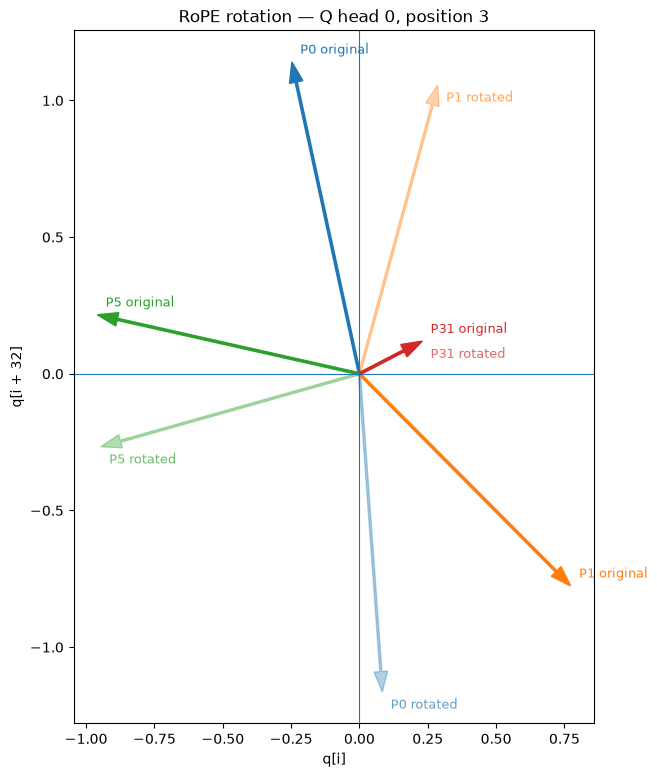

In [93]:
position = 3
pair_indices = [0, 1, 5, 31]

q = Q_heads[0, 0, position]

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

fig, ax = plt.subplots(figsize=(9, 9))

for pair_index, color in zip(pair_indices, colors):

    a = q[pair_index]
    b = q[pair_index + 32]

    angle = angles[position, pair_index]
    cos_val = torch.cos(angle)
    sin_val = torch.sin(angle)

    a_rot = a * cos_val - b * sin_val
    b_rot = a * sin_val + b * cos_val

    # Original vector — dark
    ax.arrow(
        0, 0,
        a.item(), b.item(),
        color=color,
        alpha=1.0,
        width=0.008,
        head_width=0.05,
        length_includes_head=True
    )

    # Rotated vector — light
    ax.arrow(
        0, 0,
        a_rot.item(), b_rot.item(),
        color=color,
        alpha=0.35,
        width=0.008,
        head_width=0.05,
        length_includes_head=True
    )

    # Original label
    ax.annotate(
        f"P{pair_index} original",
        (a.item(), b.item()),
        xytext=(6, 6),
        textcoords="offset points",
        color=color,
        fontsize=9
    )

    # Rotated label
    ax.annotate(
        f"P{pair_index} rotated",
        (a_rot.item(), b_rot.item()),
        xytext=(6, -12),
        textcoords="offset points",
        color=color,
        alpha=0.7,
        fontsize=9
    )

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

ax.set_xlabel("q[i]")
ax.set_ylabel("q[i + 32]")
ax.set_title(f"RoPE rotation — Q head 0, position {position}")
ax.set_aspect("equal")

plt.show()

## Apply RoPE to the entire Q head

Apply the same rotation to all 32 pairs at once, using the first half `q[:32]` and second half `q[32:]` as the two coordinates, then concatenate the halves back into a 64-dim vector. This gives the complete manually rotated Q for one position (position 3).

In the output, the **first dimensions** (fast pairs) change a lot, while the **last dimensions** belong to slow pairs and are almost unchanged: only `0.2042 → 0.2044` moves at all in the last 8, and the rest are identical to 4 decimal places.

In [87]:
position = 3

q = Q_heads[0, 0, position]

q_first = q[:32]
q_second = q[32:]

cos_pos = cos_angles[position]
sin_pos = sin_angles[position]

q_first_rotated = (
    q_first * cos_pos
    - q_second * sin_pos
)

q_second_rotated = (
    q_first * sin_pos
    + q_second * cos_pos
)

Q_manual_rotated = torch.cat(
    [q_first_rotated, q_second_rotated]
)

print("Original Q shape :", q.shape)
print("Rotated Q shape  :", Q_manual_rotated.shape)

print("\nFirst 8 dimensions:")
print("Original:", q[:8])
print("Rotated :", Q_manual_rotated[:8])

print("\nLast 8 dimensions:")
print("Original:", q[-8:])
print("Rotated :", Q_manual_rotated[-8:])

Original Q shape : torch.Size([64])
Rotated Q shape  : torch.Size([64])

First 8 dimensions:
Original: tensor([-0.2472,  0.7728,  0.0310, -1.1154,  0.9196, -0.9590, -0.3224,  0.8186], grad_fn=<SliceBackward0>)
Rotated : tensor([ 0.0837,  0.2867,  0.2218,  0.0648,  0.7989, -0.9460, -0.4802,  0.9089], grad_fn=<SliceBackward0>)

Last 8 dimensions:
Original: tensor([-0.0125,  0.1296,  0.2042,  0.5100, -0.0490,  0.9119, -1.3667,  0.1191], grad_fn=<SliceBackward0>)
Rotated : tensor([-0.0125,  0.1296,  0.2044,  0.5100, -0.0490,  0.9119, -1.3667,  0.1191], grad_fn=<SliceBackward0>)


## Verify that RoPE preserves vector length

A rotation changes the direction of a vector, but not its magnitude.

So the 64-dimensional Q vector before and after RoPE should have
the same L2 norm.

Let's verify this using our real Q head.

In [88]:
original_norm = torch.linalg.vector_norm(q)
rotated_norm = torch.linalg.vector_norm(Q_manual_rotated)

print("Original Q norm :", original_norm.item())
print("Rotated Q norm  :", rotated_norm.item())
print("Difference      :", (original_norm - rotated_norm).item())

Original Q norm : 4.903458595275879
Rotated Q norm  : 4.903458595275879
Difference      : 0.0


## Apply our manual RoPE to every token position

So far we have rotated Q for only one token position.

In the real transformer, every token position gets its own
rotation angle.

We will now apply the same operation to all six positions of
Q head 0.

The result will be a complete manually rotated Q head:
`[6 positions × 64 dimensions]`.

In [89]:
Q_head0 = Q_heads[0, 0]  # [seq_len, 64]

Q_manual_rotated = torch.empty_like(Q_head0)

for position in range(seq_len):
    q = Q_head0[position]

    q_first = q[:32]
    q_second = q[32:]

    cos_pos = cos_angles[position]
    sin_pos = sin_angles[position]

    q_first_rotated = (
        q_first * cos_pos
        - q_second * sin_pos
    )

    q_second_rotated = (
        q_first * sin_pos
        + q_second * cos_pos
    )

    Q_manual_rotated[position] = torch.cat(
        [q_first_rotated, q_second_rotated]
    )

print("Original Q head shape :", Q_head0.shape)
print("Rotated Q head shape  :", Q_manual_rotated.shape)

Original Q head shape : torch.Size([6, 64])
Rotated Q head shape  : torch.Size([6, 64])


## Compare our manual RoPE with SmolLM

Now get the real `cos` / `sin` from SmolLM's `rotary_emb` module and apply the model's own `apply_rotary_pos_emb()`. It rotates Q and K together, and we keep both (`Q_model_rotated`, `K_model_rotated`).

The model's `cos` / `sin` are `[1, 6, 64]` rather than our `[6, 32]`, because each of the 32 values is duplicated so it lines up with both halves of the head. It computes the same rotation, written as `q × cos + rotate_half(q) × sin`.

**Result:** the maximum absolute difference between our manually rotated Q head and the model's is **0.0**, an exact match.

In [90]:
from transformers.models.llama.modeling_llama import apply_rotary_pos_emb

# Position IDs for our sequence
position_ids = torch.arange(seq_len).unsqueeze(0)

# Actual cosine and sine values generated by SmolLM
cos_model, sin_model = rotary(
    Q_heads,
    position_ids
)

# Actual Hugging Face RoPE implementation (rotates Q and K)
Q_model_rotated, K_model_rotated = apply_rotary_pos_emb(
    Q_heads,
    K_heads,
    cos_model,
    sin_model
)

# Compare our manual result with the model's result
max_difference = torch.max(
    torch.abs(
        Q_manual_rotated - Q_model_rotated[0, 0]
    )
)

print("Manual Q shape :", Q_manual_rotated.shape)
print("Model Q shape  :", Q_model_rotated[0, 0].shape)

print("\nMaximum absolute difference:")
print(max_difference.item())

Manual Q shape : torch.Size([6, 64])
Model Q shape  : torch.Size([6, 64])

Maximum absolute difference:
0.0


## Why does RoPE rotate both Q and K?

Attention compares a query with a key using a dot product. With RoPE, each vector is rotated by an angle set by its own position:

`Q_rot[m] = R(m) Q[m]`, `K_rot[n] = R(n) K[n]`

Because rotations compose, the score depends only on the **offset** `n − m`:

`Q_rot[m] · K_rot[n] = Q[m]ᵀ R(n − m) K[n]`

So the same query/key pair gets the same score at positions (2, 4) as at (10, 12). Attention sees relative position without any absolute position being added to the vectors.

The cell below compares the raw score for **query position 2 / key position 4** with the score after RoPE, using the model's rotated Q and K. Q head 0 pairs with K head 0 (its GQA group). The scores differ (−17.47 raw vs. −16.43 rotated), because RoPE changes the dot product. By the identity above, the rotated score depends only on the offset of 2. The same `q` and `k` placed at, say, positions (3, 5) would give the same −16.43.

In [91]:
# Use one real Q/K pair from the model.
q = Q_heads[0, 0, 2]
k = K_heads[0, 0, 4]

# Unrotated similarity
raw_score = torch.dot(q, k)

# Get the model's rotated Q and K
q_rot = Q_model_rotated[0, 0, 2]
k_rot = K_model_rotated[0, 0, 4]

# Rotated similarity
rope_score = torch.dot(q_rot, k_rot)

print("Q position :", 2)
print("K position :", 4)

print("\nRaw Q · K:")
print(raw_score.item())

print("\nRotated Q · Rotated K:")
print(rope_score.item())

Q position : 2
K position : 4

Raw Q · K:
-17.47028350830078

Rotated Q · Rotated K:
-16.428550720214844
